In [96]:
from ccka.models.kernel import KernelModel
from ccka.circuits.angleEmbeddingKernel import quackEmbeddingCircuit
from ccka.aligner.kta import fullKTA, centroidBasedKTA, quackKTA, randomKTA, greedyKTA
import pennylane as qml
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import os
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [97]:
def load_data(dataset_path):
    data = jnp.load(dataset_path, allow_pickle=True).item()
    X = jnp.asarray(data['x_train'])
    y = jnp.asarray(data['y_train'])
    #x_test = jnp.asarray(data['x_test'])
    #y_test = jnp.asarray(data['y_test'])

    #X_combined = jnp.concatenate([X, x_test], axis=0)
    #y_combined = jnp.concatenate([y, y_test], axis=0)

    return X, y

X, y = load_data('../data/corners.npy')
X.shape

(100, 2)

In [98]:
def run_experiment(method, dataset, dataset_path, centroids, num_iterations, noise_level):

    print(f"Running {method} on {dataset} with centroids={centroids} and iterations={num_iterations}")
    
    X, y = load_data(dataset_path)

    kernel = quackEmbeddingCircuit(
                                num_qubits = 4,
                                reps = 5,
                                reupload = True,
                                noisy=True,
                                noise_level=noise_level
                        )
    init_weights = kernel.init_weights()
    model = KernelModel(circuit = kernel, device_name= 'default.mixed', diff_method=None)

    if method == 'fullKTA':
        aligner = fullKTA(
            kernel_model= model,
            data = X,
            labels = y,
            matrix_type='regular',
            split_size=0.75,
            learning_rate=0.1,
            optimizer= 'adam',
            epochs=num_iterations
        )
    
    elif method == 'centroidBasedKTA':
        num_iterations = int(num_iterations / 10)
        aligner = centroidBasedKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    clustering='regular',
                    split_size=0.75,
                    centroids= centroids,
                    lambda_co=0.0,
                    lambda_kao=0.0,
                    epochs=num_iterations,
                    eps=0.001,
                    alpha=0.01
        )
    
    elif method == 'greedyKTA':
        aligner = greedyKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    split_size=0.75,
                    greedy_samples= centroids,
                    landmark_points= 10,
                    learning_rate=0.1,
                    optimizer= 'adam',
                    epochs=num_iterations
        )
    
    elif method == 'randomKTA':
        aligner = randomKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    split_size=0.75,
                    random_samples= centroids,
                    landmark_points=10,
                    learning_rate=0.1,
                    optimizer= 'adam',
                    epochs=num_iterations
        )

    history = aligner.align()

    if method == 'centroidBasedKTA':
        num_iterations = num_iterations * 10

    return history['test_accuracy_history'][-1]

In [99]:
# ── global matplotlib style (publication-ready) ───────────────────────────
mpl.rcParams.update({
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':      'stix',
    'axes.labelsize':        10,
    'axes.titlesize':        10,
    'xtick.labelsize':       9,
    'ytick.labelsize':       9,
    'legend.fontsize':       8,
    'legend.title_fontsize': 8,
    'figure.dpi':            300,
    'savefig.dpi':           300,
    'axes.linewidth':        0.8,
    'xtick.major.width':     0.8,
    'ytick.major.width':     0.8,
    'xtick.minor.width':     0.5,
    'ytick.minor.width':     0.5,
    'lines.linewidth':       1.6,
    'patch.linewidth':       0.6,
})

# ── publication color palette (colorblind-safe, print-safe) ───────────────
# Based on Paul Tol's colorblind-safe palette
METHOD_STYLES = {
    'fullKTA': {
        'color':     '#0077BB',    # blue
        'marker':    'o',
        'linestyle': '-',
        'bar_color': '#0077BB',
        'hatch':     '',
    },
    'centroidBasedKTA': {
        'color':     '#EE7733',    # orange
        'marker':    's',
        'linestyle': '--',
        'bar_color': '#EE7733',
        'hatch':     '//',
    },
    'randomKTA': {
        'color':     '#009988',    # teal
        'marker':    '^',
        'linestyle': '-.',
        'bar_color': '#009988',
        'hatch':     'xx',
    },
    'greedyKTA': {
        'color':     '#CC3311',    # vermillion
        'marker':    'D',
        'linestyle': ':',
        'bar_color': '#CC3311',
        'hatch':     '\\\\',
    },
}

# Fallback styles for unexpected extra methods
_EXTRA_STYLES = [
    {'color': '#009988', 'marker': '^', 'linestyle': '-.', 'bar_color': '#009988', 'hatch': 'xx'},
    {'color': '#CC3311', 'marker': 'D', 'linestyle': ':',  'bar_color': '#CC3311', 'hatch': '\\\\'},
    {'color': '#AA3377', 'marker': 'v', 'linestyle': '-',  'bar_color': '#AA3377', 'hatch': '..'},
]

INITIAL_BAR_COLOR = '#4477AA'   # darker blue  — "Initial"
FINAL_BAR_COLOR   = '#EE6677'   # muted red    — "Final"


def _get_style(method, methods):
    if method in METHOD_STYLES:
        return METHOD_STYLES[method]
    idx = [m for m in methods if m not in METHOD_STYLES].index(method)
    return _EXTRA_STYLES[idx % len(_EXTRA_STYLES)]


In [100]:
# ── accuracy vs noise level panel ──────────────────────────────────────────

def plot_accuracy_vs_noise(
    accuracy_results,
    dataset_name: str = '',
    figsize=(8, 5),
):
    """
    Plot test accuracy vs. depolarising noise level,
    one line per method, on a single axes.

    Parameters
    ----------
    accuracy_results : list[dict]
        Output of the experiment loop. Each dict must contain:
        'method', 'noise_level', 'test_accuracy'.
    dataset_name : str
        Optional dataset label appended to the figure title.
    figsize : tuple
        Overall figure size in inches.
    """
    df = pd.DataFrame(accuracy_results)

    # Average over any repeated runs at the same (method, noise_level)
    df_agg = (
        df.groupby(['method', 'noise_level'])['test_accuracy']
        .mean()
        .reset_index()
    )

    noise_vals = sorted(df_agg['noise_level'].unique())
    plot_methods = df_agg['method'].unique()

    # ── figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')

    suffix = f' — {dataset_name}' if dataset_name else ''
    ax.set_title(
        f'Test Accuracy vs. Depolarising Noise Level{suffix}',
        fontsize=13, fontweight='bold',
    )

    for method in plot_methods:
        msub = df_agg[df_agg['method'] == method].sort_values('noise_level')
        sty  = METHOD_STYLES.get(method, {})

        ax.plot(
            msub['noise_level'],
            msub['test_accuracy'],
            label=method,
            color=sty.get('color', '#888888'),
            marker=sty.get('marker', 'o'),
            linestyle=sty.get('linestyle', '-'),
            linewidth=1.8,
            markersize=6,
            alpha=0.9,
            markerfacecolor='white',
            markeredgewidth=1.5,
        )

    # ── reference line at chance level (0.5 for binary) ───────────────────
    ax.axhline(
        0.5,
        color='#aaaaaa',
        linestyle='--',
        linewidth=0.9,
        alpha=0.7,
        label='Chance level',
    )

    # ── axes formatting ───────────────────────────────────────────────────
    ax.set_xlabel('Depolarising Noise Level (p)', fontsize=12)
    ax.set_ylabel('Test Accuracy', fontsize=12)

    ax.set_xticks(noise_vals)
    ax.set_xticklabels(
        [f'{v:.2g}' for v in noise_vals],
        fontsize=10, rotation=45, ha='right',
    )

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
    ax.tick_params(which='minor', length=2)
    ax.tick_params(axis='both', labelsize=10)

    ax.grid(linestyle=':', linewidth=0.6, alpha=0.6)
    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(
        fontsize=10,
        loc='lower left',
        framealpha=0.85,
        edgecolor='#cccccc',
        frameon=True,
        title='Method',
        title_fontsize=10,
    )

    fig.tight_layout()

    for fmt in ('png', 'pdf'):
        fig.savefig(
            f'accuracy_vs_noise.{fmt}',
            dpi=1200, bbox_inches='tight', facecolor='white',
        )
    plt.show()
    print("Saved: accuracy_vs_noise.png  /  accuracy_vs_noise.pdf")

In [ ]:
# ── accuracy vs noise level: centroid sweep — one figure per method ─────────

_CENTROID_METHOD_STYLES = {
    'centroidBasedKTA': {
        'linestyle': '-',
        'marker':    'o',
        'colors':    ['#084594', '#2171B5', '#6BAED6', '#BDD7E7'],  # blue shades
    },
    'randomKTA': {
        'linestyle': '--',
        'marker':    's',
        'colors':    ['#8B0000', '#CC2222', '#EE6677', '#F5AABB'],  # red shades
    },
    'greedyKTA': {
        'linestyle': ':',
        'marker':    '^',
        'colors':    ['#005A00', '#228833', '#66CC77', '#AAEEBB'],  # green shades
    },
}


def plot_accuracy_vs_noise_centroid_sweep(
    accuracy_results,
    centroid_values,
    dataset_name: str = '',
    figsize=(8, 5),
):
    """
    Plot test accuracy vs. depolarising noise level with one separate
    figure per method.  Within each figure every centroid count k gets
    its own line with a distinct colour shade (dark → light as k grows).

    Parameters
    ----------
    accuracy_results : list[dict]
        Each dict must contain 'method', 'noise_level', 'test_accuracy'.
        'method' is expected in the format '{method_name}, k={centroids}'
        as produced by the experiment loop.
    centroid_values : list[int]
        Ordered list of centroid counts used in the experiment
        (e.g. [2, 4, 8, 10]).
    dataset_name : str
        Optional dataset label appended to every figure title.
    figsize : tuple
        Figure size in inches (applied to each individual figure).
    """
    df = pd.DataFrame(accuracy_results)

    # Average over any repeated runs at the same (method, noise_level)
    df_agg = (
        df.groupby(['method', 'noise_level'])['test_accuracy']
        .mean()
        .reset_index()
    )

    noise_vals = sorted(df_agg['noise_level'].unique())
    suffix     = f' — {dataset_name}' if dataset_name else ''

    # ── one figure per method ─────────────────────────────────────────────
    for base_method, sty in _CENTROID_METHOD_STYLES.items():

        fig, ax = plt.subplots(figsize=figsize, facecolor='white')

        ax.set_title(
            f'{base_method} — Test Accuracy vs. Noise Level{suffix}',
            fontsize=13, fontweight='bold',
        )

        handles = []

        # ── one line per centroid value ───────────────────────────────────
        for k_idx, k in enumerate(centroid_values):
            label = f'{base_method}, k={k}'
            msub  = df_agg[df_agg['method'] == label].sort_values('noise_level')

            if msub.empty:
                continue

            color = sty['colors'][k_idx % len(sty['colors'])]

            line, = ax.plot(
                msub['noise_level'],
                msub['test_accuracy'],
                label=f'k = {k}',
                color=color,
                marker=sty['marker'],
                linestyle=sty['linestyle'],
                linewidth=1.8,
                markersize=6,
                alpha=0.9,
                markerfacecolor='white',
                markeredgewidth=1.5,
            )
            handles.append(line)

        # ── reference line at chance level ────────────────────────────────
        ax.axhline(
            0.5,
            color='#aaaaaa',
            linestyle='--',
            linewidth=0.9,
            alpha=0.7,
            label='Chance level',
        )

        # ── axes formatting ───────────────────────────────────────────────
        ax.set_xlabel('Depolarising Noise Level (p)', fontsize=12)
        ax.set_ylabel('Test Accuracy', fontsize=12)

        ax.set_xticks(noise_vals)
        ax.set_xticklabels(
            [f'{v:.2g}' for v in noise_vals],
            fontsize=10, rotation=45, ha='right',
        )

        ax.set_ylim(0, 1.05)
        ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
        ax.tick_params(which='minor', length=2)
        ax.tick_params(axis='both', labelsize=10)

        ax.grid(linestyle=':', linewidth=0.6, alpha=0.6)
        ax.spines[['top', 'right']].set_visible(False)

        ax.legend(
            handles=handles,
            fontsize=10,
            loc='lower left',
            framealpha=0.85,
            edgecolor='#cccccc',
            frameon=True,
            title='Centroid Count',
            title_fontsize=10,
        )

        fig.tight_layout()

        fname = f'accuracy_vs_noise_{base_method}'
        for fmt in ('png', 'pdf'):
            fig.savefig(
                f'{fname}.{fmt}',
                dpi=1200, bbox_inches='tight', facecolor='white',
            )
        plt.show()
        print(f"Saved: {fname}.png  /  {fname}.pdf")

In [102]:
#Experiment Configuarations

noise_levels = [0.0, 0.001, 0.01, 0.05, 0.1]
methods = ['fullKTA', 'centroidBasedKTA', 'randomKTA', 'greedyKTA']
centroid_values = [2, 4, 6, 8, 10]

Running experiment for noise level: 0.0
Running fullKTA on corners with centroids=4 and iterations=50


[FullKTA] KTA alignment: 100%|██████████| 50/50 [01:06<00:00,  1.32s/it]


Method: fullKTA, Noise Level: 0.0, Test Accuracy: 0.9600
Running centroidBasedKTA on corners with centroids=4 and iterations=50


[CentroidBasedKTA] KTA alignment: 100%|██████████| 5/5 [00:09<00:00,  1.94s/it]


Method: centroidBasedKTA, Noise Level: 0.0, Test Accuracy: 0.9200
Running randomKTA on corners with centroids=4 and iterations=50


...

Method: centroidBasedKTA, Noise Level: 0.1, Test Accuracy: 0.4400
Running randomKTA on corners with centroids=4 and iterations=50


[RandomKTA] KTA alignment: 100%|██████████| 50/50 [00:44<00:00,  1.12it/s]


Method: randomKTA, Noise Level: 0.1, Test Accuracy: 0.4400
Running greedyKTA on corners with centroids=4 and iterations=50


[GreedyKTA] KTA alignment: 100%|██████████| 50/50 [00:57<00:00,  1.15s/it]


Method: greedyKTA, Noise Level: 0.1, Test Accuracy: 0.4400


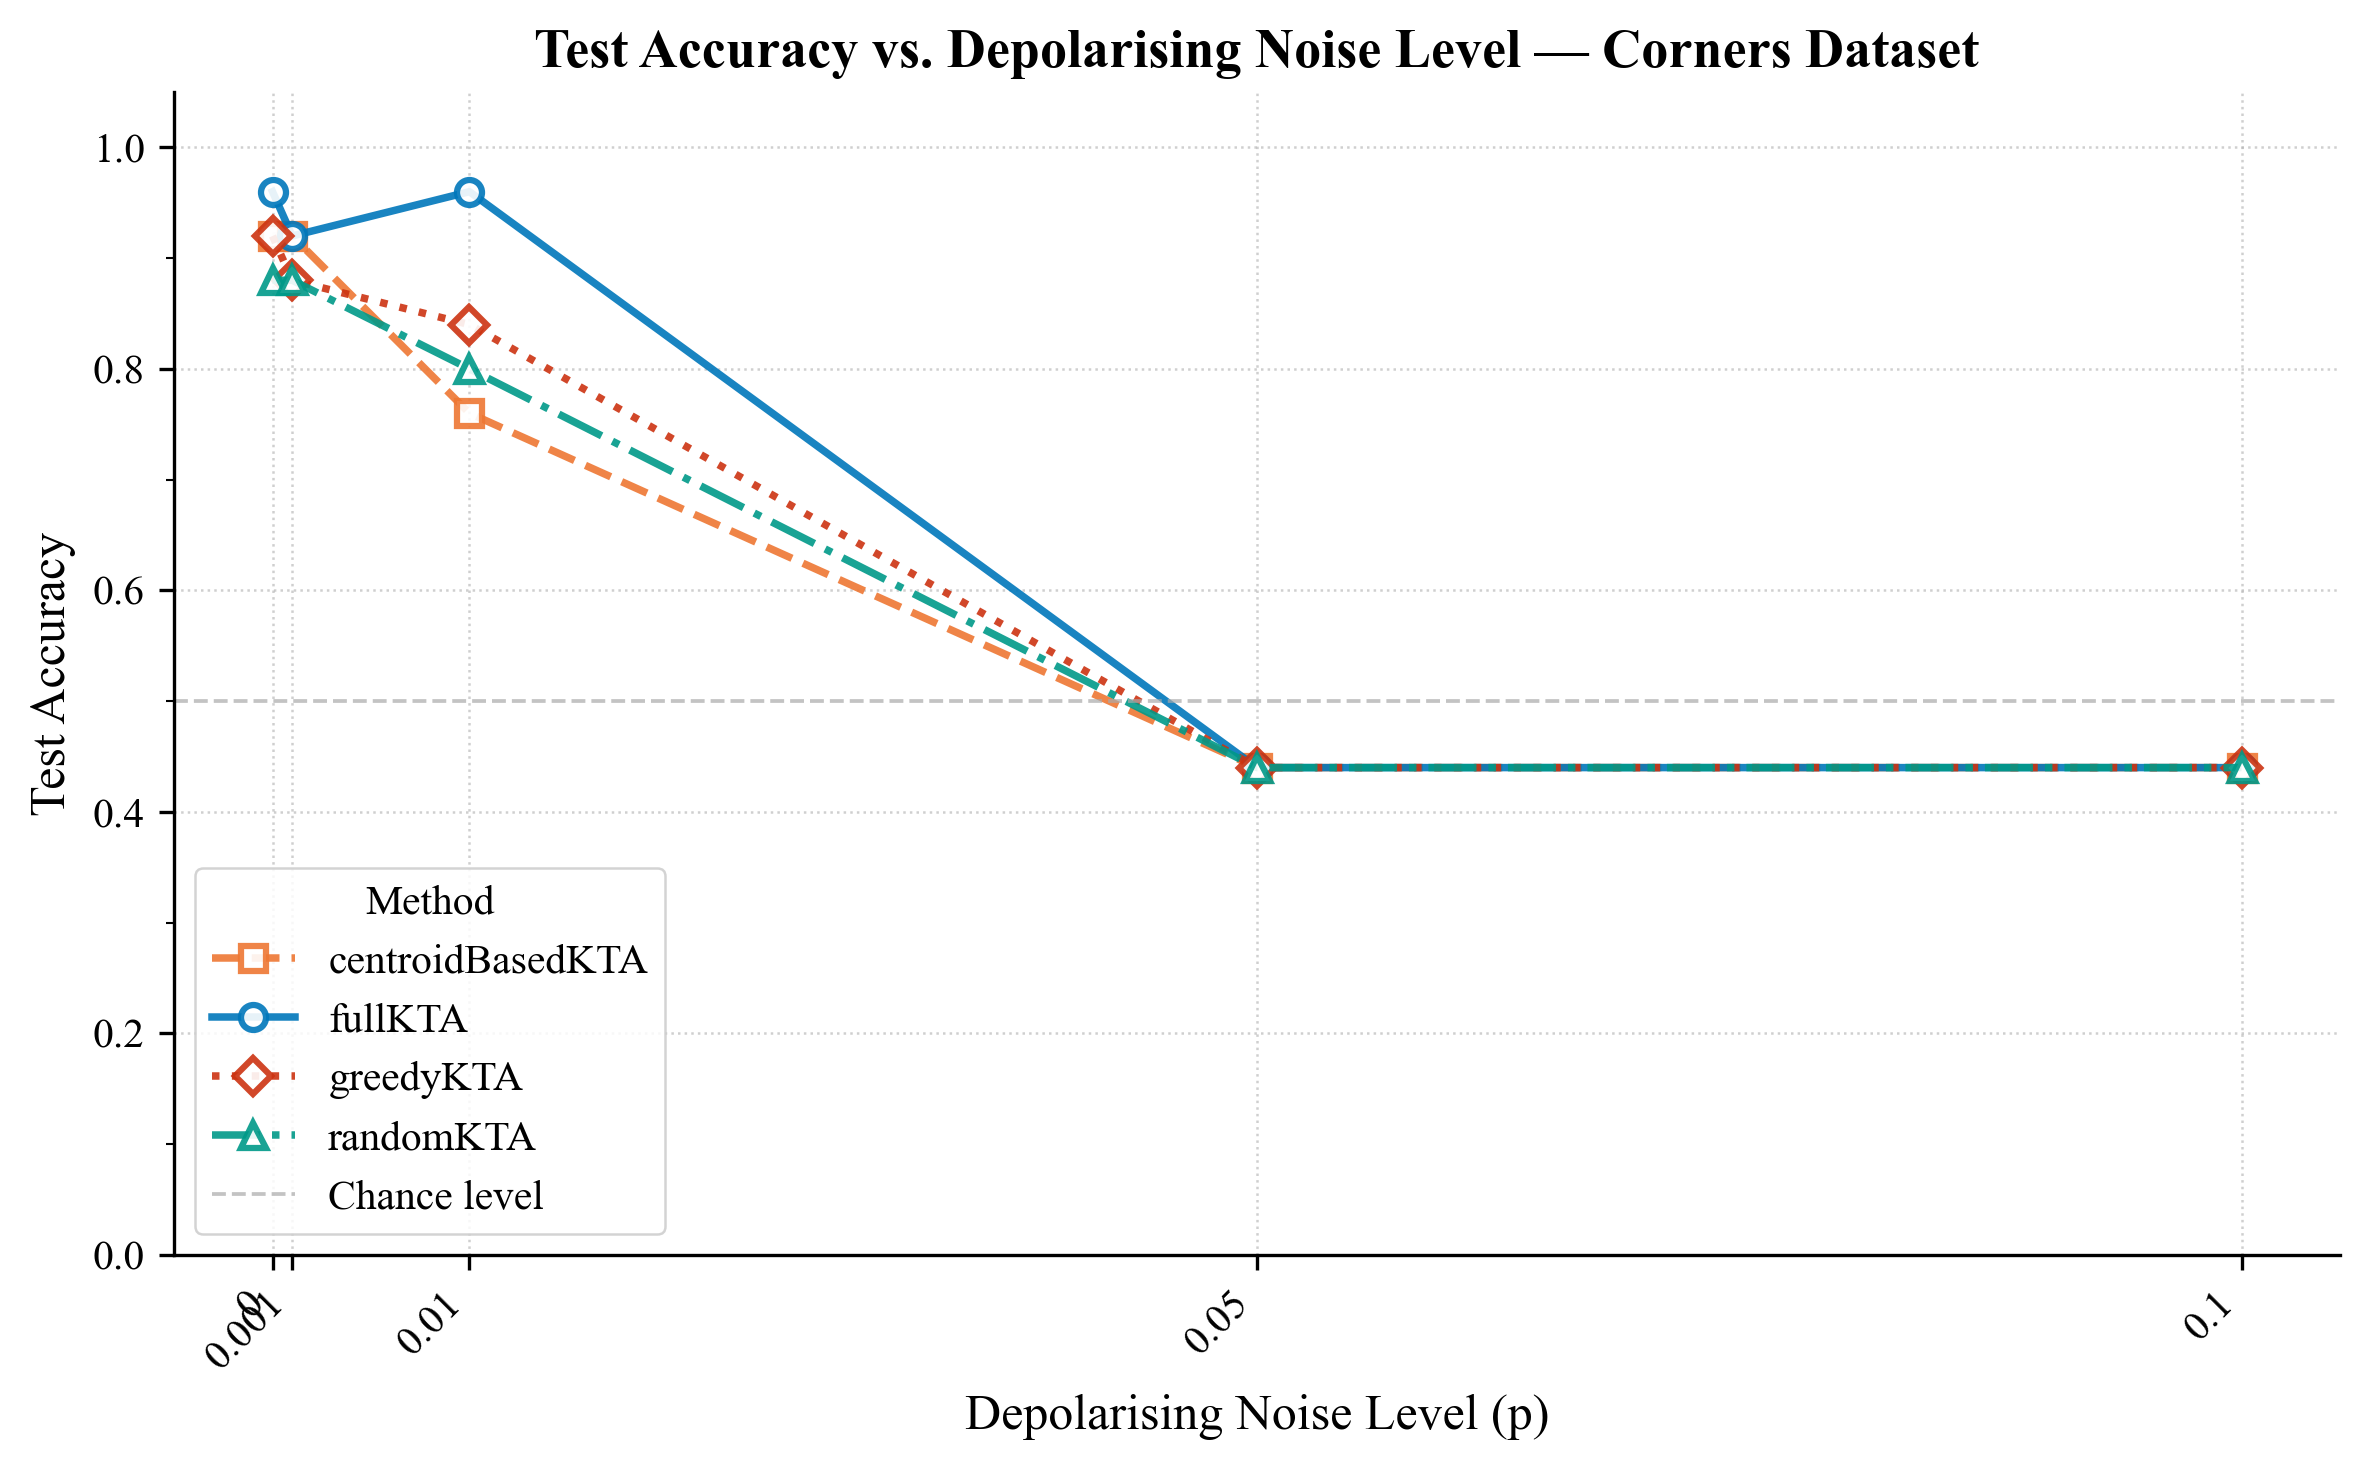

Saved: accuracy_vs_noise.png  /  accuracy_vs_noise.pdf


In [103]:
# Experiment 1: Method Comparison at Varying Noise Levels (Test accuracy vs. depolarizing noise )

accuracy_results = []
for noise_level in noise_levels:
    print(f"Running experiment for noise level: {noise_level}")
    for method in methods:
        accuracy = run_experiment(method, 'corners', '../data/corners.npy', centroids=4, num_iterations=50, noise_level=noise_level)
        print(f"Method: {method}, Noise Level: {noise_level}, Test Accuracy: {accuracy:.4f}")
        accuracy_results.append({'method': method, 'noise_level': noise_level, 'test_accuracy': accuracy})

plot_accuracy_vs_noise(accuracy_results, dataset_name='Corners Dataset')

Running experiment for noise level: 0.0
Running centroidBasedKTA on corners with centroids=2 and iterations=20


[CentroidBasedKTA] KTA alignment: 100%|██████████| 2/2 [00:07<00:00,  3.53s/it]


Centroids: 2, Noise Level: 0.0, Test Accuracy: 0.8400
Running randomKTA on corners with centroids=2 and iterations=20


[RandomKTA] KTA alignment: 100%|██████████| 20/20 [00:28<00:00,  1.45s/it]


Centroids: 2, Noise Level: 0.0, Test Accuracy: 0.8800
Running greedyKTA on corners with centroids=2 and iterations=20


...

Centroids: 10, Noise Level: 0.1, Test Accuracy: 0.4400
Running randomKTA on corners with centroids=10 and iterations=20


[RandomKTA] KTA alignment: 100%|██████████| 20/20 [00:32<00:00,  1.65s/it]


Centroids: 10, Noise Level: 0.1, Test Accuracy: 0.4400
Running greedyKTA on corners with centroids=10 and iterations=20


[GreedyKTA] KTA alignment: 100%|██████████| 20/20 [00:37<00:00,  1.88s/it]


Centroids: 10, Noise Level: 0.1, Test Accuracy: 0.4400


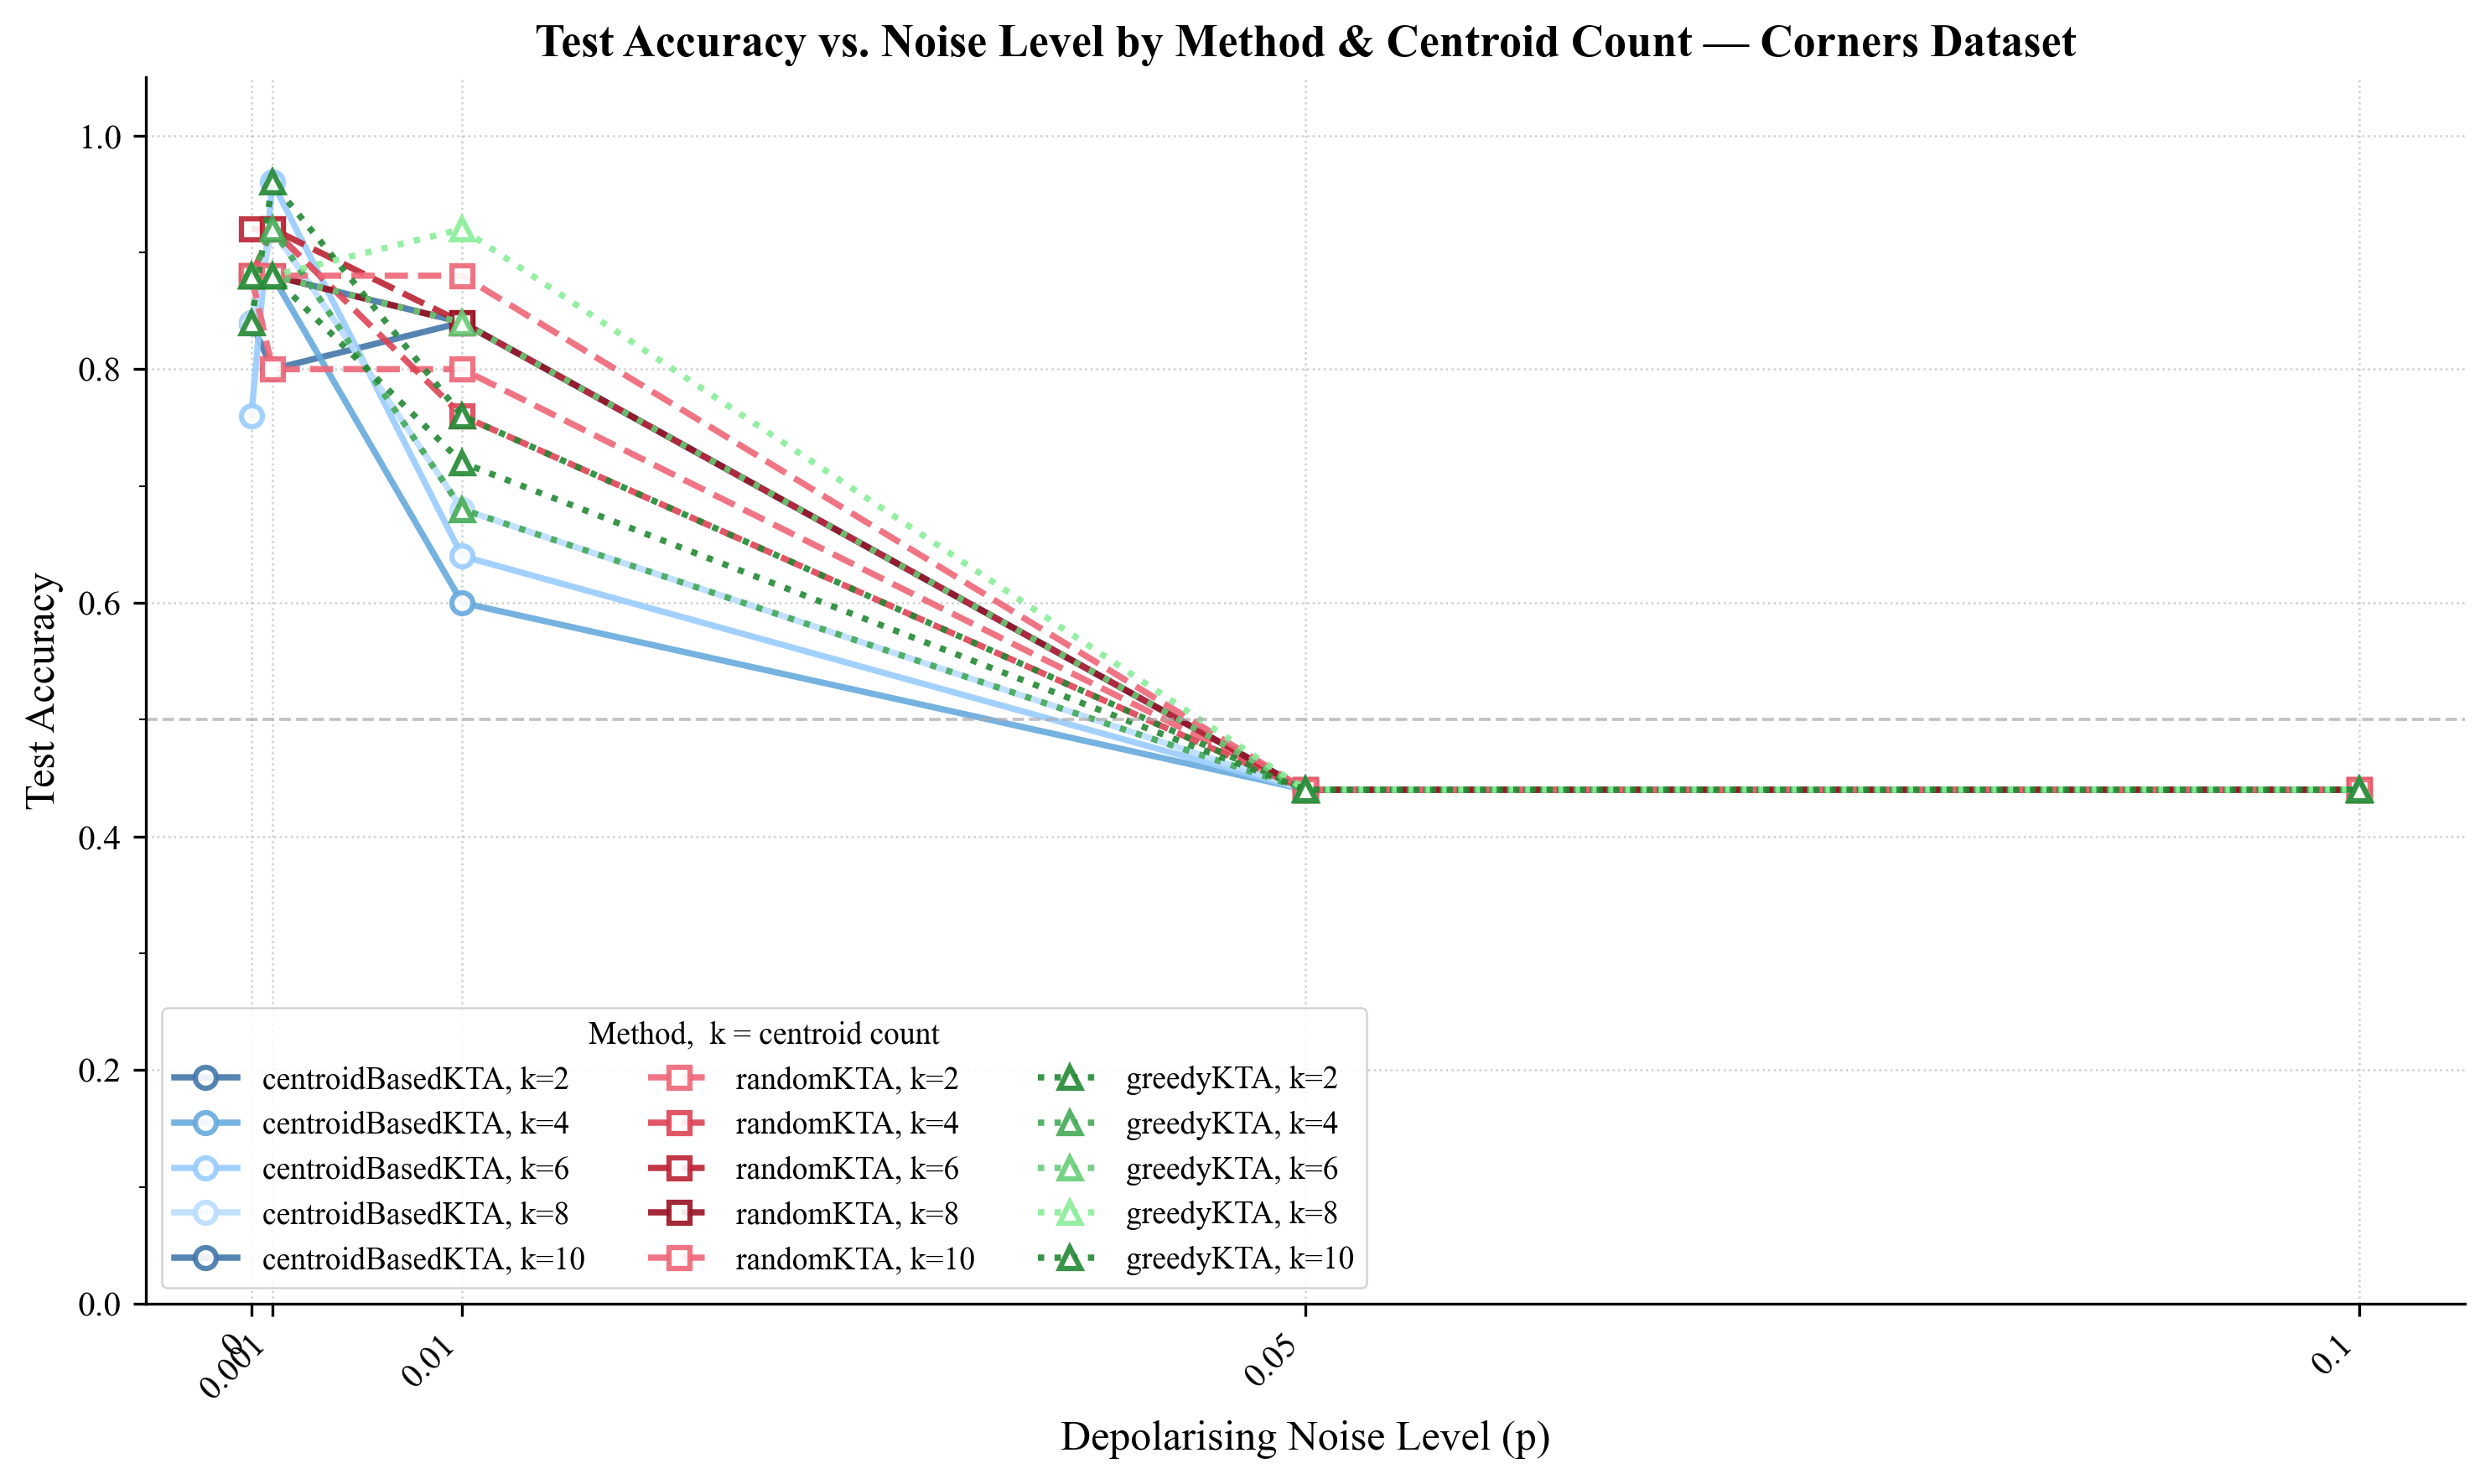

Saved: accuracy_vs_noise_centroid_sweep.png  /  accuracy_vs_noise_centroid_sweep.pdf


In [104]:
# Experiment 2: Effect of Centroid Count at Fixed Noise Level (: Test accuracy vs. noise for varying sub-centroid counts k ∈ {2, 4, 8, 10)
methods = ['centroidBasedKTA', 'randomKTA', 'greedyKTA']
for noise_level in noise_levels:
    print(f"Running experiment for noise level: {noise_level}")
    for centroids in centroid_values:
        for method in methods:
            accuracy = run_experiment(method, 'corners', '../data/corners.npy', centroids=centroids, num_iterations=20, noise_level=noise_level)
            print(f"Centroids: {centroids}, Noise Level: {noise_level}, Test Accuracy: {accuracy:.4f}")
            accuracy_results.append({'method': f'{method}, k={centroids}', 'noise_level': noise_level, 'test_accuracy': accuracy})

plot_accuracy_vs_noise_centroid_sweep(accuracy_results, centroid_values=centroid_values, dataset_name='Corners Dataset')